# Vision Transformer (ViT) — From Scratch to Fine-tuning

**IT3103 Advanced Topics in AI | Week 15 Tutorial**

In this notebook, you will:
1. Understand how images are tokenized into patches
2. Build a ViT model from scratch in PyTorch
3. Train it on CIFAR-10 and observe limitations with small data
4. Fine-tune a pre-trained ViT and compare performance
5. Visualize attention maps to understand what ViT learns

## 1. Setup & Imports

In [31]:
# Install required packages (run once)
# !pip install torch torchvision timm matplotlib numpy

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [33]:
# ── Fast CIFAR-10 fetch (run once, ~seconds) ──────────────────────────────
# The default torchvision source (cs.toronto.edu) is heavily throttled and can
# take ~1 HOUR for the 170 MB tarball. Instead we pull the *identical* file
# (md5 c58f30108f718f92721af3b95e74349a) from a HuggingFace mirror in seconds.
# torchvision's download=True below then just verifies + extracts it locally.
import os
os.makedirs('data', exist_ok=True)
if not os.path.exists('data/cifar-10-python.tar.gz'):
    from huggingface_hub import hf_hub_download  # pre-installed on Colab
    hf_hub_download(
        repo_id="liangnanying/cifar-10-python",
        filename="cifar-10-python.tar.gz",
        repo_type="dataset",
        local_dir="data",
    )
    print("CIFAR-10 tarball ready in ./data")
else:
    print("CIFAR-10 tarball already present in ./data")

CIFAR-10 tarball already present in ./data


## 2. Patch Embedding from First Principles

The core idea of ViT: split an image into non-overlapping patches and treat each patch as a token.

Image shape: torch.Size([3, 32, 32])
Label: frog


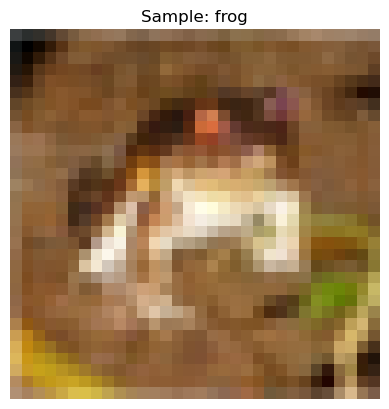

In [34]:
# Load a sample image from CIFAR-10 for demonstration
transform = transforms.Compose([transforms.ToTensor()])
cifar10 = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

sample_image, label = cifar10[0]
print(f"Image shape: {sample_image.shape}")  # [3, 32, 32]
print(f"Label: {cifar10.classes[label]}")

plt.imshow(sample_image.permute(1, 2, 0))
plt.title(f"Sample: {cifar10.classes[label]}")
plt.axis('off')
plt.show()

In [35]:
# Manual patch extraction
def extract_patches(image, patch_size):
    """
    Split image into non-overlapping patches.
    
    Args:
        image: tensor of shape [C, H, W]
        patch_size: size of each patch (e.g., 4 for 4x4)
    
    Returns:
        patches: tensor of shape [num_patches, patch_size*patch_size*C]
    """
    C, H, W = image.shape
    assert H % patch_size == 0 and W % patch_size == 0, "Image dimensions must be divisible by patch size"
    
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    
    # Reshape: [C, H, W] -> [C, num_patches_h, patch_size, num_patches_w, patch_size]
    patches = image.reshape(C, num_patches_h, patch_size, num_patches_w, patch_size)
    # Rearrange: [num_patches_h, num_patches_w, C, patch_size, patch_size]
    patches = patches.permute(1, 3, 0, 2, 4)
    # Flatten: [num_patches, patch_dim]
    patches = patches.reshape(-1, C * patch_size * patch_size)
    
    return patches

# Extract patches from sample image (32x32 with patch_size=4 -> 64 patches)
patch_size = 4
patches = extract_patches(sample_image, patch_size)
print(f"Number of patches: {patches.shape[0]}")
print(f"Patch dimension: {patches.shape[1]}")
print(f"  = {patch_size}x{patch_size}x3 = {patch_size*patch_size*3}")

Number of patches: 64
Patch dimension: 48
  = 4x4x3 = 48


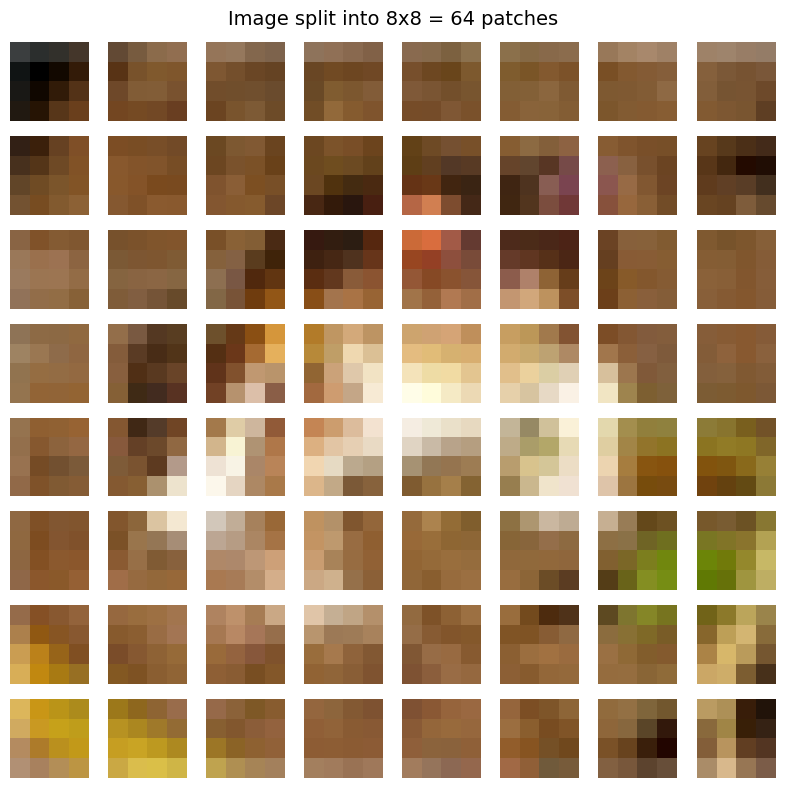

In [36]:
# Visualize the patches
num_patches_per_side = 32 // patch_size  # 8

fig, axes = plt.subplots(num_patches_per_side, num_patches_per_side, figsize=(8, 8))
fig.suptitle(f"Image split into {num_patches_per_side}x{num_patches_per_side} = {patches.shape[0]} patches", fontsize=14)

for i in range(num_patches_per_side):
    for j in range(num_patches_per_side):
        idx = i * num_patches_per_side + j
        patch = patches[idx].reshape(3, patch_size, patch_size).permute(1, 2, 0)
        axes[i, j].imshow(patch.numpy())
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

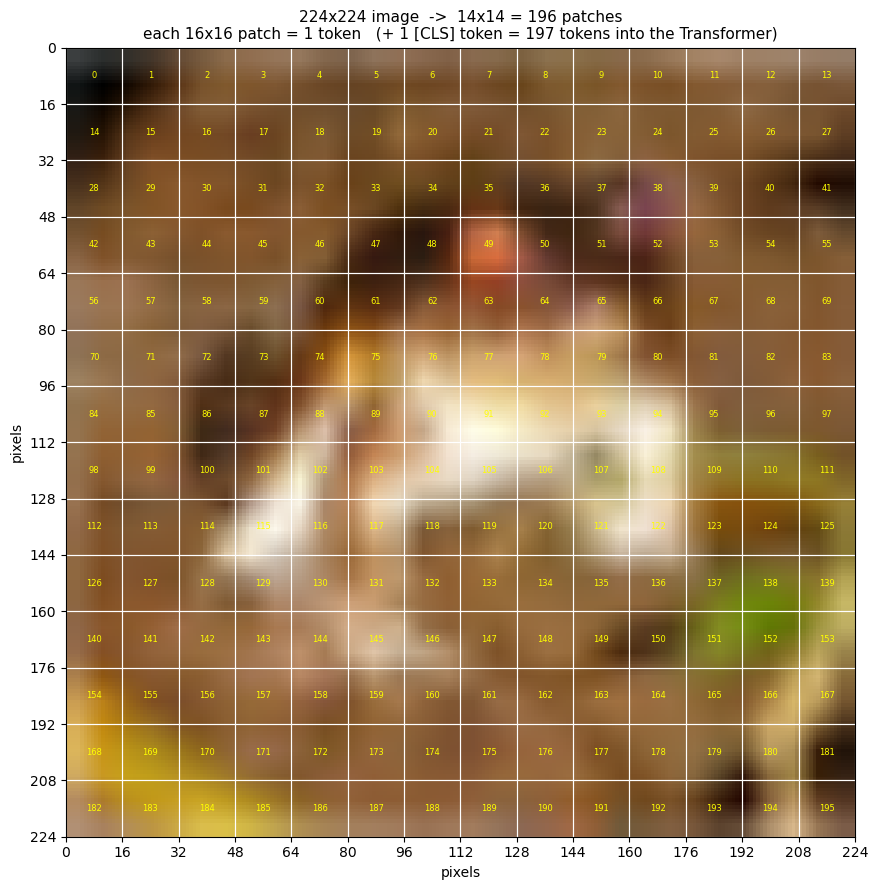

Patches per side : 14
Total patches (N): 196
Sequence length  : 196 + 1 [CLS] = 197


In [37]:
# ── The standard ViT-B/16 case: a 224x224 image -> 14x14 = 196 patch tokens ──
# The demo above used 32x32 CIFAR with patch_size=4 (8x8=64 patches).
# The original ViT paper uses 224x224 images with 16x16 patches. Let's visualize
# that grid to make "each patch = one token" concrete.
from matplotlib.patches import Rectangle

IMG_SIZE   = 224
PATCH_SIZE = 16
GRID       = IMG_SIZE // PATCH_SIZE      # 224 // 16 = 14 patches per side
N_PATCHES  = GRID * GRID                 # 14 x 14 = 196 tokens

# Upscale the CIFAR sample to 224x224 so the 14x14 grid is exact.
# (Swap in any PIL image resized to 224x224 for a sharper picture.)
img_224 = transforms.Resize((IMG_SIZE, IMG_SIZE))(sample_image)   # [3,224,224]
img_np  = np.clip(img_224.permute(1, 2, 0).numpy(), 0, 1)

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(img_np, extent=[0, IMG_SIZE, IMG_SIZE, 0])   # pixel coords, origin top-left

for row in range(GRID):
    for col in range(GRID):
        x, y = col * PATCH_SIZE, row * PATCH_SIZE
        token_idx = row * GRID + col                    # patch (row,col) -> token index
        ax.add_patch(Rectangle((x, y), PATCH_SIZE, PATCH_SIZE,
                               fill=False, edgecolor='white', linewidth=0.8))
        ax.text(x + PATCH_SIZE / 2, y + PATCH_SIZE / 2, str(token_idx),
                color='yellow', fontsize=6, ha='center', va='center')

ax.set_title(f"{IMG_SIZE}x{IMG_SIZE} image  ->  {GRID}x{GRID} = {N_PATCHES} patches\n"
             f"each {PATCH_SIZE}x{PATCH_SIZE} patch = 1 token   "
             f"(+ 1 [CLS] token = {N_PATCHES + 1} tokens into the Transformer)",
             fontsize=11)
ax.set_xticks(np.arange(0, IMG_SIZE + 1, PATCH_SIZE))
ax.set_yticks(np.arange(0, IMG_SIZE + 1, PATCH_SIZE))
ax.set_xlabel("pixels"); ax.set_ylabel("pixels")
plt.tight_layout()
plt.show()

print(f"Patches per side : {GRID}")
print(f"Total patches (N): {N_PATCHES}")
print(f"Sequence length  : {N_PATCHES} + 1 [CLS] = {N_PATCHES + 1}")

In [38]:
# Efficient implementation using Conv2d (same result!)
class PatchEmbedding(nn.Module):
    """Convert image into patch embeddings using Conv2d."""
    
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Conv2d with kernel_size=stride=patch_size extracts and projects patches
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )
    
    def forward(self, x):
        # x: [batch, 3, H, W]
        x = self.projection(x)  # [batch, embed_dim, H/P, W/P]
        x = x.flatten(2)         # [batch, embed_dim, num_patches]
        x = x.transpose(1, 2)    # [batch, num_patches, embed_dim]
        return x

# Test it
patch_embed = PatchEmbedding(img_size=32, patch_size=4, embed_dim=256)
test_input = sample_image.unsqueeze(0)  # Add batch dim
embedded = patch_embed(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {embedded.shape}  (batch, num_patches, embed_dim)")

Input shape:  torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 64, 256])  (batch, num_patches, embed_dim)


## 3. Building ViT Step by Step

Now let's build the complete ViT architecture:
1. Patch Embedding
2. [CLS] Token + Position Embeddings
3. Transformer Encoder Blocks
4. Classification Head

In [39]:
class TransformerBlock(nn.Module):
    """A single Transformer encoder block with pre-norm."""
    
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        # Pre-norm: LayerNorm before attention (ViT style)
        norm_x = self.norm1(x)
        # average_attn_weights=False -> return PER-HEAD attention weights of shape
        # [batch, num_heads, seq_len, seq_len]. (By default nn.MultiheadAttention
        # averages over heads and returns [batch, seq_len, seq_len], which the
        # attention-visualization cell can't index per head.)
        attn_out, attn_weights = self.attn(norm_x, norm_x, norm_x, average_attn_weights=False)
        x = x + attn_out  # Residual connection
        
        # Pre-norm: LayerNorm before MLP
        x = x + self.mlp(self.norm2(x))  # Residual connection
        
        return x, attn_weights

In [40]:
class ViT(nn.Module):
    """Vision Transformer for image classification."""
    
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10,
                 embed_dim=256, depth=4, num_heads=8, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        
        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        # 2. [CLS] Token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # 3. Position Embeddings (learnable)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        
        # 4. Transformer Encoder
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        
        # 5. Classification Head
        self.head = nn.Linear(embed_dim, num_classes)
        
        # Initialize weights
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
    
    def forward(self, x, return_attention=False):
        batch_size = x.shape[0]
        
        # Patch embedding
        x = self.patch_embed(x)  # [B, num_patches, embed_dim]
        
        # Prepend [CLS] token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # [B, num_patches+1, embed_dim]
        
        # Add position embeddings
        x = self.pos_drop(x + self.pos_embed)
        
        # Transformer encoder blocks
        attention_maps = []
        for block in self.blocks:
            x, attn_weights = block(x)
            attention_maps.append(attn_weights)
        
        # Layer norm
        x = self.norm(x)
        
        # Classification: use [CLS] token output
        cls_output = x[:, 0]  # [B, embed_dim]
        logits = self.head(cls_output)
        
        if return_attention:
            return logits, attention_maps
        return logits

# Create model
model = ViT(
    img_size=32, patch_size=4, num_classes=10,
    embed_dim=256, depth=4, num_heads=8
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(f"  Patches: {model.patch_embed.num_patches}")
print(f"  Sequence length: {model.patch_embed.num_patches + 1} (patches + [CLS])")
print(f"  Embed dim: 256")
print(f"  Depth: 4 layers")
print(f"  Heads: 8")

Total parameters: 3,191,562

Model architecture:
  Patches: 64
  Sequence length: 65 (patches + [CLS])
  Embed dim: 256
  Depth: 4 layers
  Heads: 8


## 4. Training on CIFAR-10 (From Scratch)

Let's train our ViT from scratch and see how it performs with limited data.

In [41]:
# Data loading with augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")
print(f"Classes: {trainset.classes}")

Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [42]:
# Training function
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return 100. * correct / total

In [43]:
# Train from scratch (reduced epochs for demonstration)
model_scratch = ViT(
    img_size=32, patch_size=4, num_classes=10,
    embed_dim=256, depth=4, num_heads=8, dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_scratch.parameters(), lr=3e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

num_epochs = 20
train_losses, train_accs, test_accs = [], [], []

print("Training ViT from scratch on CIFAR-10...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>8}")
print("-" * 50)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_scratch, trainloader, criterion, optimizer)
    test_acc = evaluate(model_scratch, testloader)
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"{epoch+1:>5} | {train_loss:>10.4f} | {train_acc:>8.2f}% | {test_acc:>7.2f}%")

print(f"\nFinal test accuracy (from scratch): {test_accs[-1]:.2f}%")

Training ViT from scratch on CIFAR-10...
Epoch | Train Loss | Train Acc | Test Acc
--------------------------------------------------


    5 |     1.1080 |    60.02% |   62.06%
   10 |     0.8628 |    69.25% |   68.57%
   15 |     0.6739 |    75.92% |   75.14%
   20 |     0.5835 |    79.38% |   76.48%

Final test accuracy (from scratch): 76.48%


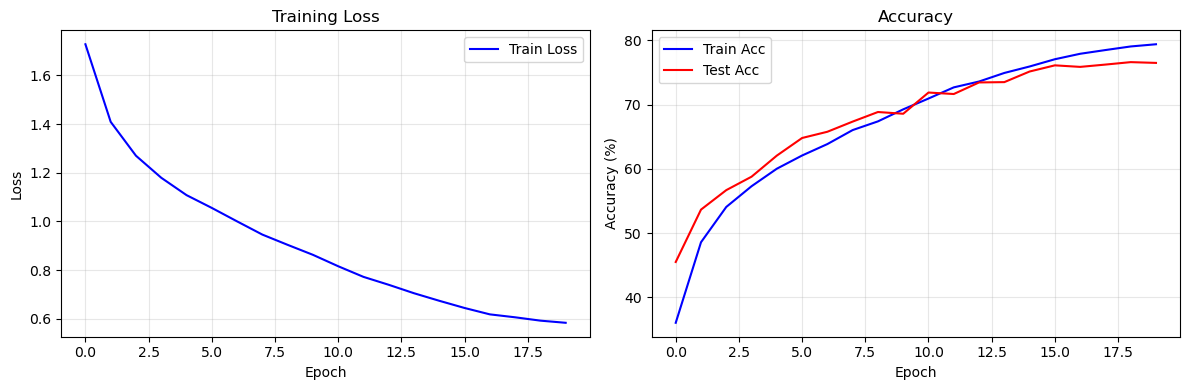

Note: ViT from scratch on small datasets (CIFAR-10) typically reaches ~70-80% accuracy.
A CNN like ResNet can reach ~93%+ on the same task.
This demonstrates why ViT needs large-scale pre-training!


In [44]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, 'b-', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, 'b-', label='Train Acc')
ax2.plot(test_accs, 'r-', label='Test Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: ViT from scratch on small datasets (CIFAR-10) typically reaches ~70-80% accuracy.")
print("A CNN like ResNet can reach ~93%+ on the same task.")
print("This demonstrates why ViT needs large-scale pre-training!")

## 5. Fine-tuning a Pre-trained ViT

Now let's see the difference when using a pre-trained ViT backbone (via the `timm` library).

In [45]:
import timm

# Load a pre-trained ViT (tiny variant for speed)
model_pretrained = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=10)
model_pretrained = model_pretrained.to(device)

print(f"Pre-trained ViT parameters: {sum(p.numel() for p in model_pretrained.parameters()):,}")
print(f"Expected input size: 224x224 (we'll resize CIFAR-10)")

Pre-trained ViT parameters: 5,526,346
Expected input size: 224x224 (we'll resize CIFAR-10)


In [46]:
# Data transforms for pre-trained model (resize to 224x224)
transform_pretrained_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # ImageNet stats
])

transform_pretrained_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

trainset_pt = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_pretrained_train)
testset_pt = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_pretrained_test)

trainloader_pt = DataLoader(trainset_pt, batch_size=64, shuffle=True, num_workers=2)
testloader_pt = DataLoader(testset_pt, batch_size=64, shuffle=False, num_workers=2)

In [47]:
# Fine-tune with lower learning rate
optimizer_pt = optim.AdamW(model_pretrained.parameters(), lr=1e-4, weight_decay=0.01)
scheduler_pt = optim.lr_scheduler.CosineAnnealingLR(optimizer_pt, T_max=5)

num_epochs_ft = 5  # Much fewer epochs needed!
ft_test_accs = []

print("Fine-tuning pre-trained ViT on CIFAR-10...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>8}")
print("-" * 50)

for epoch in range(num_epochs_ft):
    train_loss, train_acc = train_epoch(model_pretrained, trainloader_pt, criterion, optimizer_pt)
    test_acc = evaluate(model_pretrained, testloader_pt)
    scheduler_pt.step()
    ft_test_accs.append(test_acc)
    print(f"{epoch+1:>5} | {train_loss:>10.4f} | {train_acc:>8.2f}% | {test_acc:>7.2f}%")

print(f"\nFinal test accuracy (fine-tuned): {ft_test_accs[-1]:.2f}%")
print(f"Compare with from-scratch: {test_accs[-1]:.2f}%")
print(f"\nImprovement: {ft_test_accs[-1] - test_accs[-1]:.2f}% (with only {num_epochs_ft} epochs!)")

Fine-tuning pre-trained ViT on CIFAR-10...
Epoch | Train Loss | Train Acc | Test Acc
--------------------------------------------------
    1 |     0.2419 |    91.98% |   95.31%
    2 |     0.0878 |    97.02% |   95.00%
    3 |     0.0427 |    98.54% |   96.04%
    4 |     0.0116 |    99.65% |   97.17%
    5 |     0.0030 |    99.94% |   97.44%

Final test accuracy (fine-tuned): 97.44%
Compare with from-scratch: 76.48%

Improvement: 20.96% (with only 5 epochs!)


## 5b. Visualizing the Learned Patch-Embedding Filters (Paper Figure 7)

The ViT patch embedding is "just a linear projection" — but that projection matrix **is** a stack of filters. For a 16x16 patch with 3 channels, each output embedding dimension corresponds to one filter of shape `3 x 16 x 16` (equivalently, the weight of the `Conv2d(3, embed_dim, kernel_size=16, stride=16)`).

Figure 7 (left) of the ViT paper visualizes the **top principal components** of these learned filters. Below we pull the filters from the pre-trained model, run PCA (via SVD) over them, and plot the leading components as 16x16 RGB images. They look like Gabor-style edge/color detectors — even though ViT has no built-in convolutional bias, it *learns* CNN-like low-level features.

Patch-embedding weight (filters): (192, 3, 16, 16)
  -> 192 filters, each 3x16x16 (one per embedding dimension)


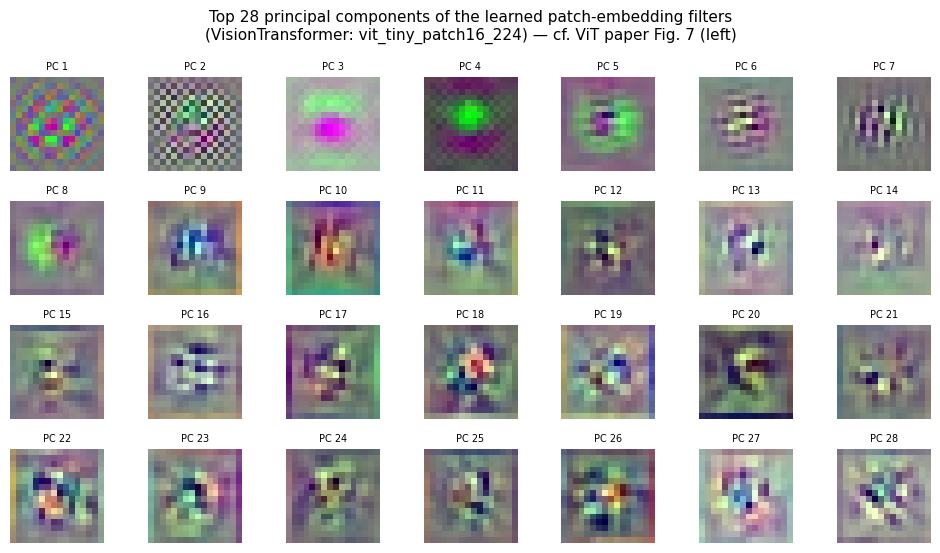

Variance explained by top 10 components: 21.2%
Note: components resemble Gabor-like edge/color detectors — ViT learns CNN-style low-level filters from data, with no convolutional prior.


In [48]:
# ── Extract the patch-embedding filters and visualize their top PCA components ──
# timm ViT stores the patch embedding as a Conv2d at model.patch_embed.proj
# Its weight has shape [embed_dim, 3, 16, 16] -> one 16x16x3 filter per embed dim.
proj = model_pretrained.patch_embed.proj          # Conv2d(3, embed_dim, k=16, s=16)
W = proj.weight.detach().cpu().float()            # [embed_dim, 3, 16, 16]
embed_dim, C, P, _ = W.shape
print(f"Patch-embedding weight (filters): {tuple(W.shape)}")
print(f"  -> {embed_dim} filters, each {C}x{P}x{P} (one per embedding dimension)")

# Flatten each filter to a vector and run PCA via SVD.
Wf = W.reshape(embed_dim, -1).numpy()             # [embed_dim, 3*16*16]
Wf = Wf - Wf.mean(axis=0, keepdims=True)          # center
U, S, Vt = np.linalg.svd(Wf, full_matrices=False)
components = Vt.reshape(-1, C, P, P)              # each row -> a 16x16x3 "eigen-filter"

def to_rgb(f):
    """Normalize a [3,16,16] filter to [0,1] RGB for display."""
    f = f.transpose(1, 2, 0)                       # -> 16x16x3
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    return f

# Plot the top-28 principal components (like the paper's Figure 7 left).
n_show = 28
cols = 7
rows = int(np.ceil(n_show / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.4))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(to_rgb(components[i]), interpolation='nearest')
        ax.set_title(f'PC {i+1}', fontsize=7)
    ax.axis('off')
fig.suptitle(f'Top {n_show} principal components of the learned patch-embedding filters\n'
             f'({model_pretrained.__class__.__name__}: vit_tiny_patch16_224) — cf. ViT paper Fig. 7 (left)',
             fontsize=11)
plt.tight_layout()
plt.show()

# How much variance the leading components explain.
var_ratio = (S**2) / (S**2).sum()
print(f"Variance explained by top 10 components: {var_ratio[:10].sum():.1%}")
print("Note: components resemble Gabor-like edge/color detectors — ViT learns "
      "CNN-style low-level filters from data, with no convolutional prior.")

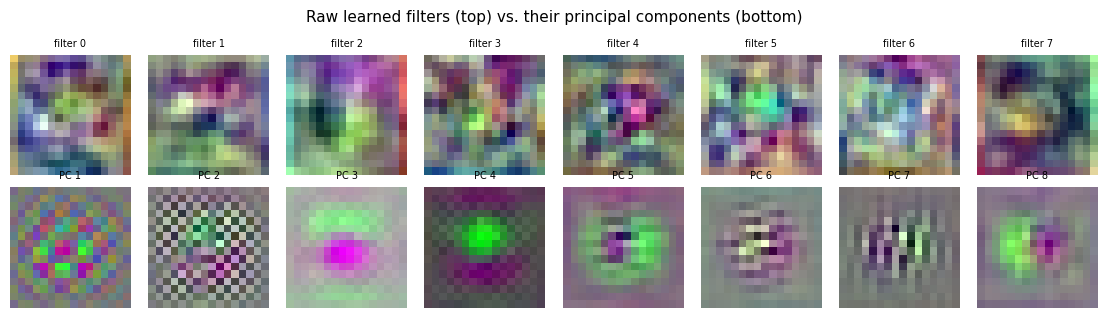

Raw filters: individual learned 16x16 kernels — often noisy/redundant, and
each is just one of 192 embedding dimensions (arbitrary ordering).
PCA components: the dominant SHARED directions across all filters — cleaner,
ordered by importance, and what the paper plots to reveal the Gabor-like structure.


In [49]:
# ── Raw learned filters vs. their principal components, side by side ──
# Reuses W (raw filters [embed_dim,3,16,16]), `components`, and to_rgb() from the
# previous cell. Top row: a few individual filters straight from the weight matrix.
# Bottom row: the leading PCA components of ALL filters.
n = 8  # how many to show in each row

fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3.2))

# Top row: raw filters (just the first n embedding dimensions, as-is)
for j in range(n):
    axes[0, j].imshow(to_rgb(W[j].numpy()), interpolation='nearest')
    axes[0, j].set_title(f'filter {j}', fontsize=7)
    axes[0, j].axis('off')

# Bottom row: top-n principal components
for j in range(n):
    axes[1, j].imshow(to_rgb(components[j]), interpolation='nearest')
    axes[1, j].set_title(f'PC {j+1}', fontsize=7)
    axes[1, j].axis('off')

axes[0, 0].set_ylabel('raw', fontsize=9)
axes[1, 0].set_ylabel('PCA', fontsize=9)
fig.suptitle('Raw learned filters (top) vs. their principal components (bottom)',
             fontsize=11)
plt.tight_layout()
plt.show()

print("Raw filters: individual learned 16x16 kernels — often noisy/redundant, and")
print("each is just one of 192 embedding dimensions (arbitrary ordering).")
print("PCA components: the dominant SHARED directions across all filters — cleaner,")
print("ordered by importance, and what the paper plots to reveal the Gabor-like structure.")

## 6. Attention Visualization

Let's visualize what the ViT attends to, showing how different layers capture different patterns.

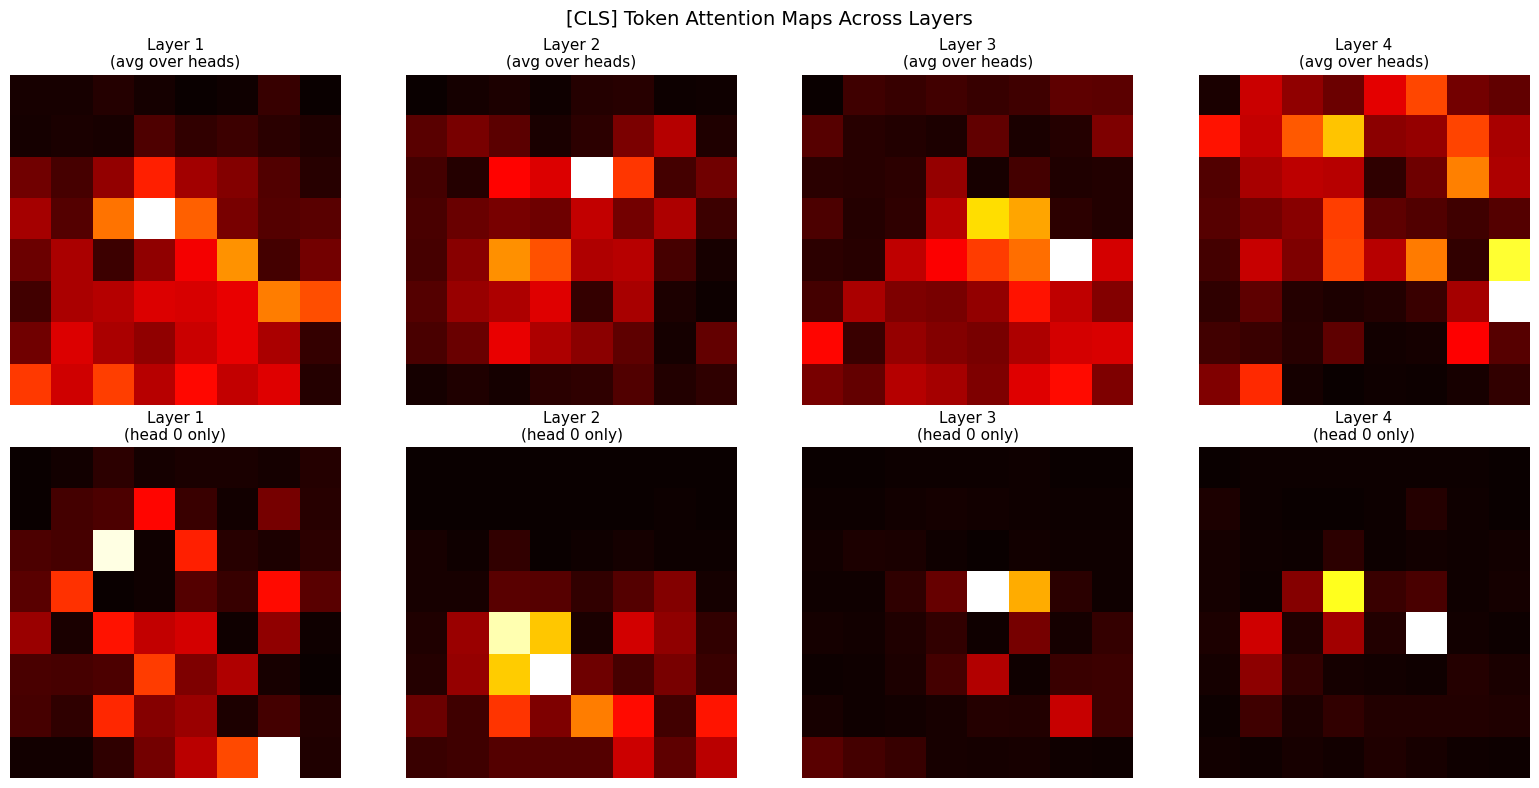

In [50]:
def visualize_attention(model, image, patch_size=4, img_size=32):
    """
    Visualize attention maps from the [CLS] token to all patches.
    """
    model.eval()
    
    # Get attention maps
    with torch.no_grad():
        _, attention_maps = model(image.unsqueeze(0).to(device), return_attention=True)
    
    num_patches_per_side = img_size // patch_size
    num_layers = len(attention_maps)
    
    fig, axes = plt.subplots(2, num_layers, figsize=(4 * num_layers, 8))
    if num_layers == 1:
        axes = axes.reshape(2, 1)
    
    for layer_idx, attn in enumerate(attention_maps):
        # attn is the weight tensor from nn.MultiheadAttention. It can be:
        #   [batch, num_heads, seq_len, seq_len]  (average_attn_weights=False), or
        #   [batch, seq_len, seq_len]             (default: already head-averaged).
        # Normalize to [batch, num_heads, seq_len, seq_len] so indexing works either way.
        if attn.dim() == 3:
            attn = attn.unsqueeze(1)  # add a singleton head dimension

        # Attention from [CLS] (position 0) to all patch tokens (positions 1:)
        cls_attn = attn[0, :, 0, 1:]  # [num_heads, num_patches]
        
        # Average over heads
        avg_attn = cls_attn.mean(0).cpu().numpy()
        avg_attn = avg_attn.reshape(num_patches_per_side, num_patches_per_side)
        
        # Plot average attention
        axes[0, layer_idx].imshow(avg_attn, cmap='hot', interpolation='nearest')
        axes[0, layer_idx].set_title(f'Layer {layer_idx+1}\n(avg over heads)', fontsize=11)
        axes[0, layer_idx].axis('off')
        
        # Plot head 0 attention (equals the avg if only one head is available)
        head0_attn = cls_attn[0].cpu().numpy()
        head0_attn = head0_attn.reshape(num_patches_per_side, num_patches_per_side)
        axes[1, layer_idx].imshow(head0_attn, cmap='hot', interpolation='nearest')
        axes[1, layer_idx].set_title(f'Layer {layer_idx+1}\n(head 0 only)', fontsize=11)
        axes[1, layer_idx].axis('off')
    
    fig.suptitle('[CLS] Token Attention Maps Across Layers', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

# Use the from-scratch model (it has our custom architecture with attention output)
sample_for_viz = transform_test(cifar10.data[0])  # Use unnormalized for viz
visualize_attention(model_scratch, transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))(transforms.ToTensor()(cifar10.data[0])))

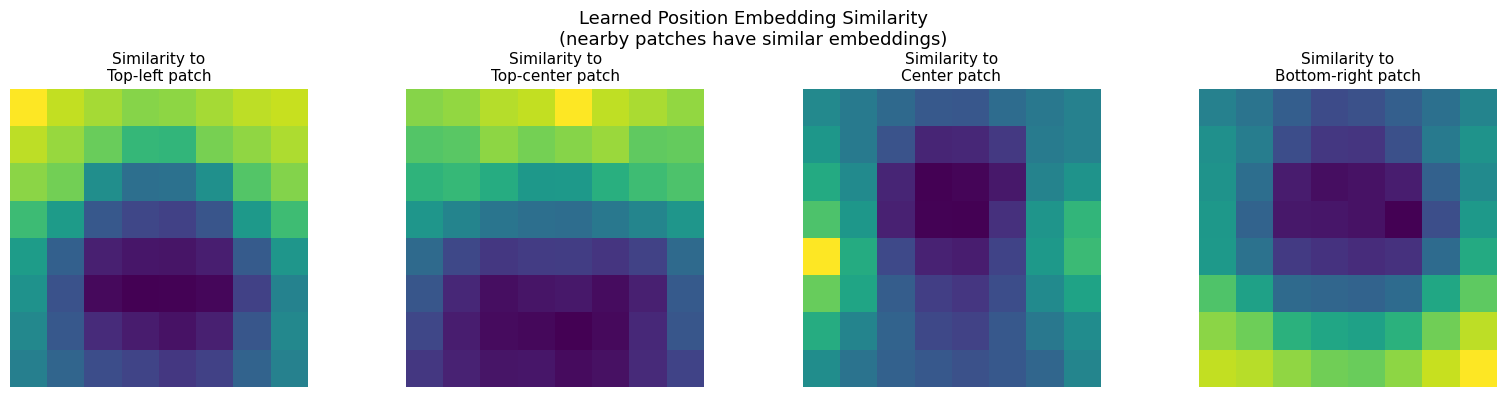

In [51]:
# Visualize learned position embeddings
pos_embed = model_scratch.pos_embed[0, 1:].detach().cpu()  # Exclude [CLS]
num_patches = pos_embed.shape[0]
num_side = int(num_patches ** 0.5)

# Compute cosine similarity between position embeddings
pos_embed_norm = pos_embed / pos_embed.norm(dim=1, keepdim=True)
similarity = pos_embed_norm @ pos_embed_norm.T

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Show similarity for 4 reference positions
positions = [0, num_side // 2, num_patches // 2, num_patches - 1]
titles = ['Top-left', 'Top-center', 'Center', 'Bottom-right']

for i, (pos, title) in enumerate(zip(positions, titles)):
    sim = similarity[pos].reshape(num_side, num_side).numpy()
    axes[i].imshow(sim, cmap='viridis', interpolation='nearest')
    axes[i].set_title(f'Similarity to\n{title} patch', fontsize=11)
    axes[i].axis('off')

fig.suptitle('Learned Position Embedding Similarity\n(nearby patches have similar embeddings)', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

**Key takeaways:**
1. ViT splits images into patches and treats them as tokens — simple but effective
2. From scratch on small data, ViT underperforms CNNs (lacks inductive biases)
3. Pre-trained ViT + fine-tuning achieves excellent results even with little data
4. Attention maps show ViT learns local patterns in early layers and global in later layers
5. Position embeddings automatically learn spatial structure

**Next:** In the SAM notebook, we'll see how ViT is used as a backbone for image segmentation.